# 02 — Exploratory Data Analysis: Austin Animal Shelter (Dogs & Cats)

**Goal:** understand what predicts **adoption** (`is_adopted`) for shelter animals, as preparation for a later modeling step. This notebook is **EDA only** — no cleaning, no feature engineering for a model, no training.

**Why dogs and cats are analyzed *separately, side by side* in every section (never pooled):**
1. Dog adopters and cat adopters are **different populations**.
2. **Breed distributions don't overlap** — cats are dominated by *Domestic Shorthair*; dogs spread across *Pit Bull, Labrador, Chihuahua, German Shepherd, ...*
3. **Age pushes the two species in opposite directions** (senior cats get adopted *more*, senior dogs *less*). A single pooled chart/model would average away these opposite signals.

The dataset is already cleaned and pre-merged (one row per outcome event, each outcome joined to its intake record). **We do not re-clean anything here.**

## 1. Setup & Load

### 1.1 Imports, data path & load
Load the cleaned, pre-merged dataset (already filtered to dogs & cats). `DATA_PATH` is the single knob to edit. If the processed CSV lacks the calendar columns, they are rebuilt from `intake_date` so the temporal section (§5) still works.

In [586]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Consistent species colors used everywhere in this notebook
DOG_COLOR = 'steelblue'
CAT_COLOR = 'darkorange'

# ====== EDIT THIS IF YOUR DATA LIVES ELSEWHERE ======
DATA_PATH = '../data/processed/df_full_merged.csv'   # cleaned, pre-merged, already dog/cat only
# ====================================================
df = pd.read_csv(DATA_PATH)
print('Loaded:', df.shape)

df['animal_type'].value_counts(dropna=False)

Loaded: (162765, 24)


animal_type
Dog    93962
Cat    68803
Name: count, dtype: int64

### 1.2 Target & leakage columns
`is_adopted` is the prediction target. The leakage columns are known only *after* the outcome, so they are listed here only to keep them out of any later model — never used as features.

In [ ]:
# For reference only — never feed these to a model.
LEAKAGE_COLS = [
    'outcome_type', 'outcome_subtype', 'outcome_date',
    'length_of_stay_days'
]
TARGET = 'is_adopted'
print('Leakage (excluded from features):', LEAKAGE_COLS)
print('Target:', TARGET)

Leakage (excluded from features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days', 'is_euthanasia']
Target: is_adopted


### 1.3 Derive display-only columns (`age_bucket`, `color_group`)
`age_bucket` bins `age_at_intake_days` into ordered buckets; `color_group` collapses the ~58 raw colors into families/patterns (cats' sparse warm colors folded into `Other`; dogs untouched). The distributions of these columns are plotted later in §2.

In [588]:
# --- age_bucket: bin age_at_intake_days (display-only) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = pd.cut(
    df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS, right=False
)
df['age_bucket'] = df['age_bucket'].cat.set_categories(AGE_LABELS, ordered=True)

print('age_bucket counts:')
print(df['age_bucket'].value_counts().reindex(AGE_LABELS))

age_bucket counts:
age_bucket
<2mo       34667
2-6mo      28424
6-12mo     13567
1-2yr      24098
2-5yr      39644
5-10yr     15923
10-15yr     5545
15yr+        866
Name: count, dtype: int64


In [589]:
# --- color_group: collapse ~58 raw colors into families/patterns (display-only) ---
COLOR_BASE = {
    'Black': 'Black', 'White': 'White',
    'Brown': 'Brown', 'Chocolate': 'Brown', 'Sable': 'Brown', 'Liver': 'Brown',
    'Agouti': 'Brown', 'Ruddy': 'Brown',
    'Tan': 'Tan', 'Fawn': 'Tan', 'Buff': 'Tan', 'Apricot': 'Tan', 'Gold': 'Tan', 'Yellow': 'Tan',
    'Blue': 'Blue/Gray', 'Gray': 'Blue/Gray', 'Silver': 'Blue/Gray', 'Lilac': 'Blue/Gray',
    'Red': 'Red/Orange', 'Orange': 'Red/Orange',
    'Cream': 'Cream',
}
def to_color_group(c):
    if pd.isna(c):                                              return 'Unknown'
    if 'Tabby' in c:                                            return 'Tabby'
    if 'Calico' in c:                                           return 'Calico'
    if 'Tortie' in c or 'Torbie' in c:                          return 'Tortie'
    if 'Point' in c:                                            return 'Point'
    if 'Brindle' in c:                                          return 'Brindle'
    if 'Merle' in c:                                            return 'Merle'
    if 'Tricolor' in c:                                         return 'Tricolor'
    return COLOR_BASE.get(c.split()[0], 'Other')

# apply the same grouping to BOTH colors (secondary NaN -> 'single color')
df['color_group']           = df['primary_color'].map(to_color_group)
df['secondary_color_group'] = (df['secondary_color'].map(to_color_group)
                                .replace('Unknown', 'Single color'))  # NaN = no 2nd color

# Cats have very few of these warm/solid colors -> fold into 'Other' (dogs unaffected)
CAT_MERGE_TO_OTHER = ['Tan', 'Cream', 'Brown', 'Red/Orange']
_is_cat = df['animal_type'].eq('Cat')
df.loc[_is_cat & df['color_group'].isin(CAT_MERGE_TO_OTHER), 'color_group'] = 'Other'

print('color_group counts (primary):')
print(df['color_group'].value_counts())

print('\nsecondary_color_group counts:')
print(df['secondary_color_group'].value_counts())

color_group counts (primary):
color_group
Black         40138
Tabby         31173
White         21011
Brown         16486
Tan           14769
Blue/Gray     10345
Tortie         6192
Brindle        5177
Red/Orange     3981
Tricolor       3904
Calico         3337
Point          2670
Cream          1399
Merle          1238
Other           945
Name: count, dtype: int64

secondary_color_group counts:
secondary_color_group
Single color    75534
White           53580
Black           10487
Tan              8124
Brown            7580
Blue/Gray        2175
Tabby            1352
Tricolor         1225
Brindle           977
Red/Orange        845
Cream             538
Merle             203
Calico             60
Point              41
Tortie             40
Other               4
Name: count, dtype: int64


### 1.4 Split into `dogs` / `cats` + class balance
Two convenience frames used side-by-side throughout. Prints per-species adoption rate and the `is_adopted` balance.

In [590]:
dogs = df[df['animal_type'] == 'Dog'].copy()
cats = df[df['animal_type'] == 'Cat'].copy()

# A label map so 0/1 flags render with readable names in plots
LABEL_MAP = {'is_mix': {0: 'Purebred', 1: 'Mix'}}

print(f'Dogs: {len(dogs):,} rows | adoption rate = {dogs[TARGET].mean():.3f}')
print(f'Cats: {len(cats):,} rows | adoption rate = {cats[TARGET].mean():.3f}')
print()
print('is_adopted balance (counts):')
print(pd.crosstab(df['animal_type'], df[TARGET]))

Dogs: 93,962 rows | adoption rate = 0.512
Cats: 68,803 rows | adoption rate = 0.518

is_adopted balance (counts):
is_adopted       0      1
animal_type              
Cat          33177  35626
Dog          45837  48125


## 2. Univariate Analysis
_Each feature shown for dogs and cats side by side; never pooled._

### 2.1 `age_at_intake_days` — distribution & skew
Histograms per species, plus `describe()` and skewness (right-skew flagged for a later log/bucket decision).

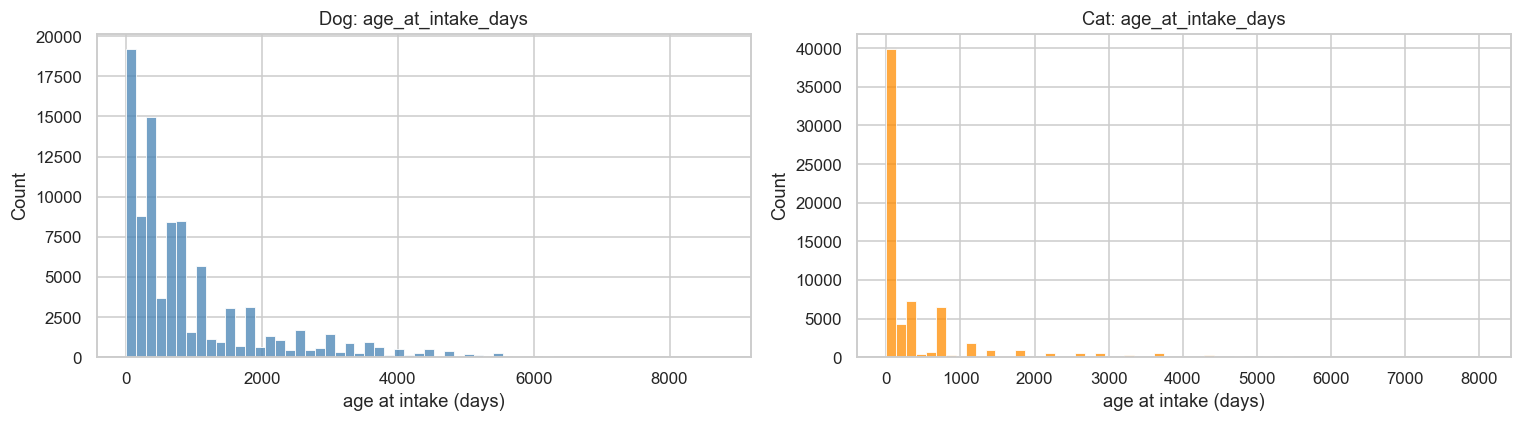

               Dog       Cat
count     93943.00  68791.00
mean        952.03    488.92
std        1105.39    939.21
min           0.00      0.00
25%         195.00     31.00
50%         614.00     83.00
75%        1117.00    429.00
max        8766.00   8036.00
skewness      1.93      3.21

Dog: skewness = 1.93  ->  STRONG right-skew -> consider log-transform or bucket
Cat: skewness = 3.21  ->  STRONG right-skew -> consider log-transform or bucket


In [591]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    sns.histplot(frame['age_at_intake_days'].dropna(), bins=60, color=color, ax=ax)
    ax.set_title(f'{sp}: age_at_intake_days')
    ax.set_xlabel('age at intake (days)')
fig.tight_layout(); plt.show()

desc = pd.concat({'Dog': dogs['age_at_intake_days'].describe(),
                  'Cat': cats['age_at_intake_days'].describe()}, axis=1)
desc.loc['skewness'] = [dogs['age_at_intake_days'].skew(), cats['age_at_intake_days'].skew()]
print(desc.round(2))
print()
for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    sk = frame['age_at_intake_days'].skew()
    flag = 'STRONG right-skew -> consider log-transform or bucket' if sk > 1 else 'mild skew'
    print(f'{sp}: skewness = {sk:.2f}  ->  {flag}')

### 2.2 `age_bucket` distribution

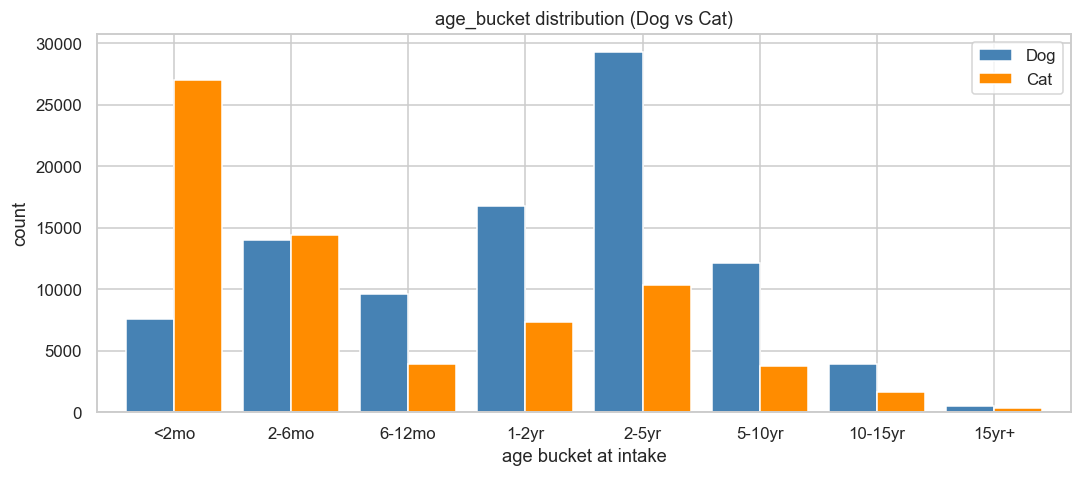

In [592]:
# bar chart of the age_bucket distribution (Dog vs Cat)
_ab = (df.groupby(['age_bucket', 'animal_type'], observed=True).size()
       .unstack(fill_value=0).reindex(AGE_LABELS))
_ab = _ab[[c for c in ['Dog', 'Cat'] if c in _ab.columns]]
ax = _ab.plot(kind='bar', figsize=(10, 4.5), width=0.82,
              color={'Dog': DOG_COLOR, 'Cat': CAT_COLOR})
ax.set_xlabel('age bucket at intake'); ax.set_ylabel('count')
ax.set_title('age_bucket distribution (Dog vs Cat)')
ax.legend(title='')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 2.3 Categorical features — `sex`, `intake_reason`, `intake_health_condition`, `is_mix`
Category proportions as pie charts (top-6 categories + `Other`), Dog vs Cat.

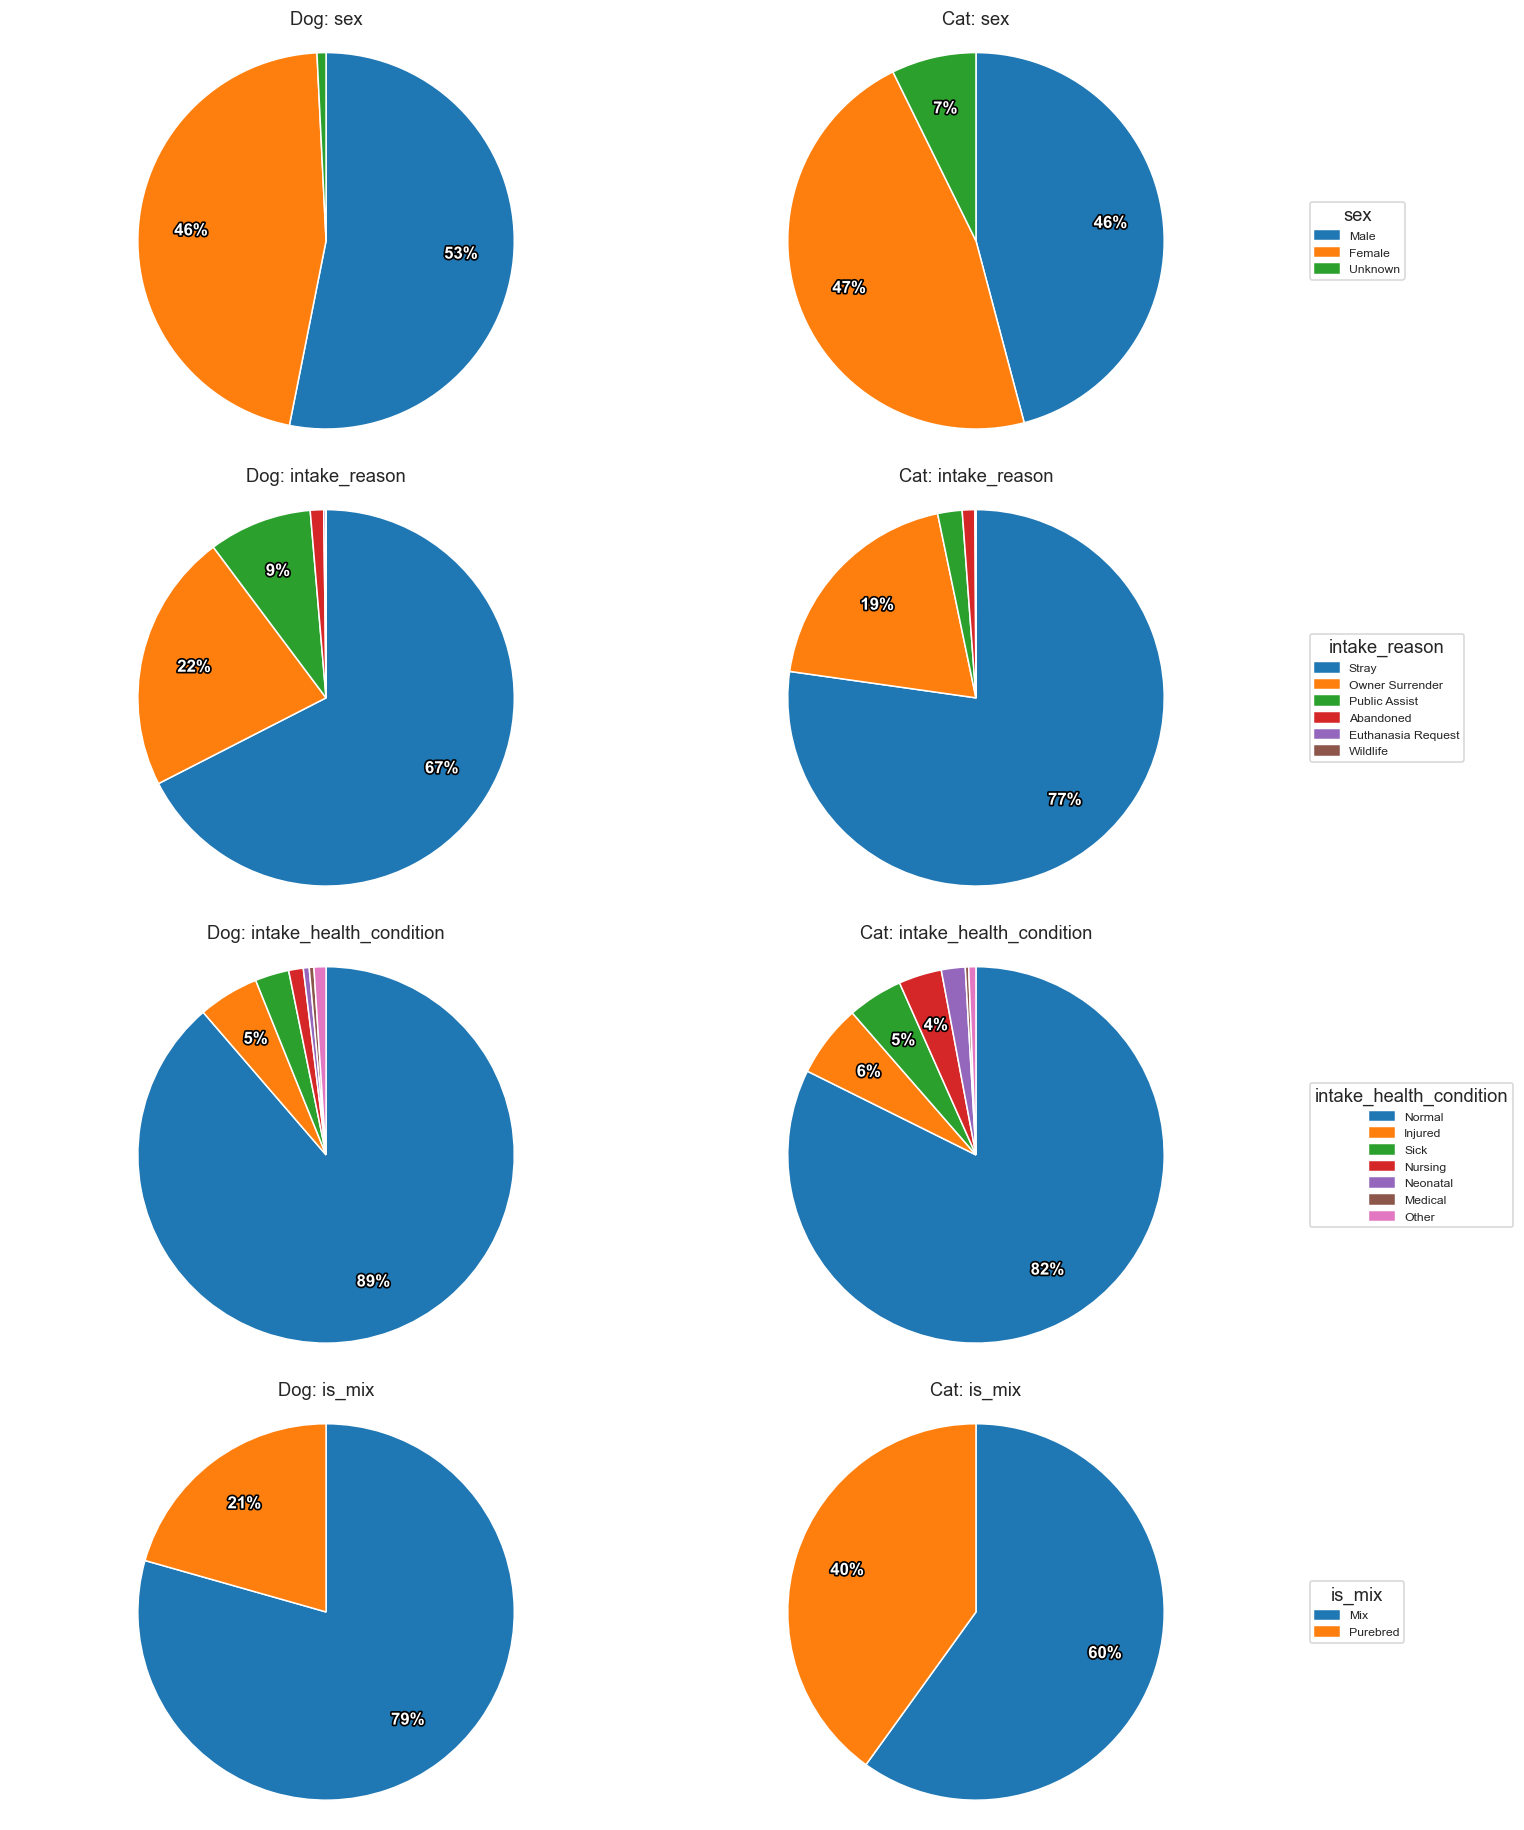

In [593]:
import matplotlib.patheffects as path_effects

cat_feats = ['sex', 'intake_reason', 'intake_health_condition', 'is_mix']
TOP_N = 6
fig, axes = plt.subplots(len(cat_feats), 2, figsize=(14, 4.2 * len(cat_feats)))

def _autopct(p):
    return f'{p:.0f}%' if p >= 3 else ''   # hide tiny slivers so labels don't overlap

for r, col in enumerate(cat_feats):
    # Determine category order ONCE across both species, keep top-N, lump rest into 'Other'.
    full_order = df[col].value_counts().index.tolist()
    keep = full_order[:TOP_N]
    has_other = len(full_order) > TOP_N
    cats_for_legend = keep + (['Other'] if has_other else [])
    cmap = plt.cm.tab20 if len(cats_for_legend) > 10 else plt.cm.tab10
    color_map = {cat: cmap(i % cmap.N) for i, cat in enumerate(cats_for_legend)}
    for c, (sp, frame) in enumerate([('Dog', dogs), ('Cat', cats)]):
        vc = frame[col].value_counts()
        sizes, slice_cats = [], []
        for cat in keep:
            sizes.append(vc.get(cat, 0)); slice_cats.append(cat)
        if has_other:
            sizes.append(vc.drop(labels=[k for k in keep if k in vc.index]).sum()); slice_cats.append('Other')
        colors = [color_map[cat] for cat in slice_cats]
        ax = axes[r, c]
        wedges, _, autotexts = ax.pie(
            sizes, colors=colors, autopct=_autopct, pctdistance=0.72,
            startangle=90, counterclock=False, normalize=True,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
        # Make the % labels clearly readable on ANY slice color: bold white + black outline.
        for t in autotexts:
            t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
            t.set_path_effects([path_effects.withStroke(linewidth=2.2, foreground='black')])
        ax.set_title(f'{sp}: {col}')
        ax.axis('equal')
    legend_labels = [str(LABEL_MAP.get(col, {}).get(cat, cat)) for cat in cats_for_legend]
    legend_handles = [plt.matplotlib.patches.Patch(color=color_map[cat]) for cat in cats_for_legend]
    axes[r, 1].legend(legend_handles, legend_labels, title=col,
                      loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.tight_layout(); plt.show()

### 2.4 `primary_breed` — TOP 15 per species (separate plots; breeds do **not** overlap)

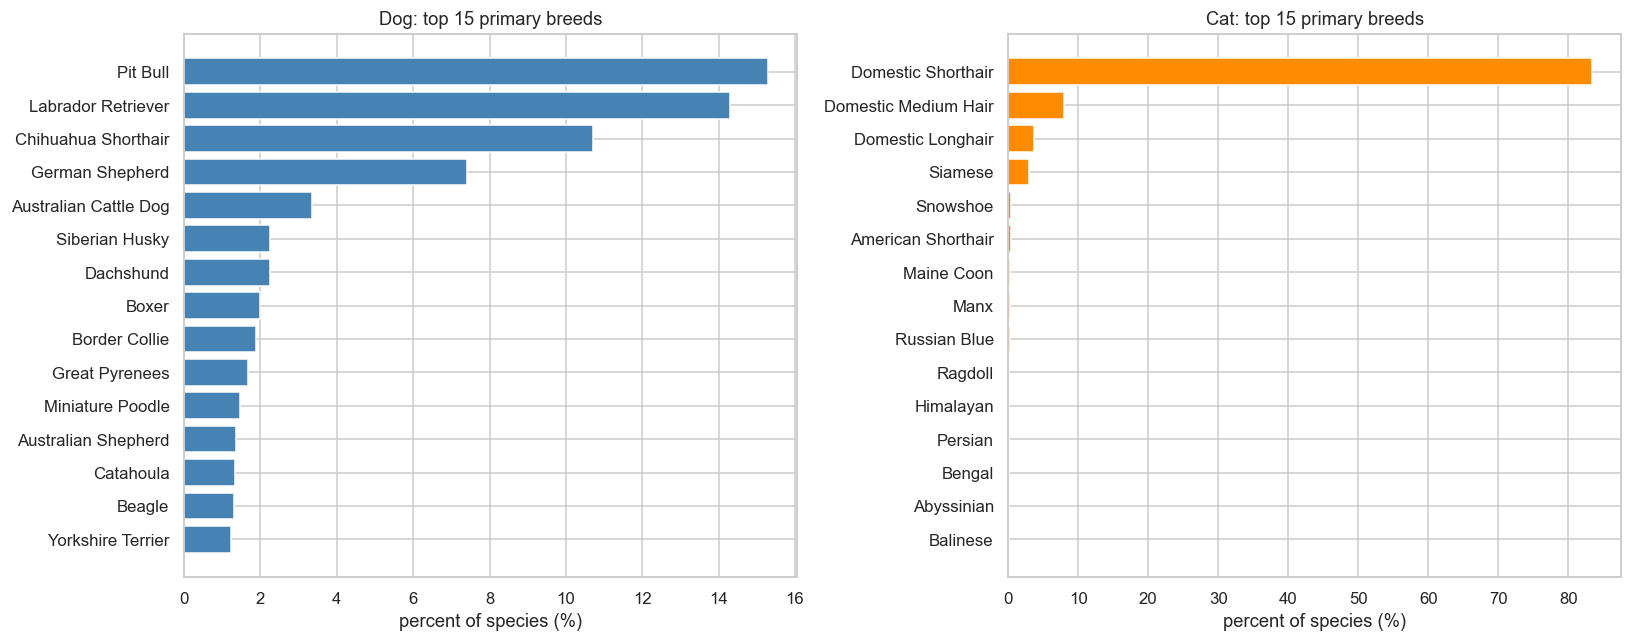

Dog: 211 unique breeds; 100 are rare (<50 rows).
Cat: 44 unique breeds; 33 are rare (<50 rows).


In [594]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    pct = frame['primary_breed'].value_counts(normalize=True).head(15) * 100
    ax.barh(pct.index[::-1], pct.values[::-1], color=color)
    ax.set_title(f'{sp}: top 15 primary breeds')
    ax.set_xlabel('percent of species (%)')
fig.tight_layout(); plt.show()

for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    vc = frame['primary_breed'].value_counts()
    rare = int((vc < 50).sum())
    print(f'{sp}: {frame["primary_breed"].nunique()} unique breeds; '
          f'{rare} are rare (<50 rows).')

### 2.5 `color_group` distribution

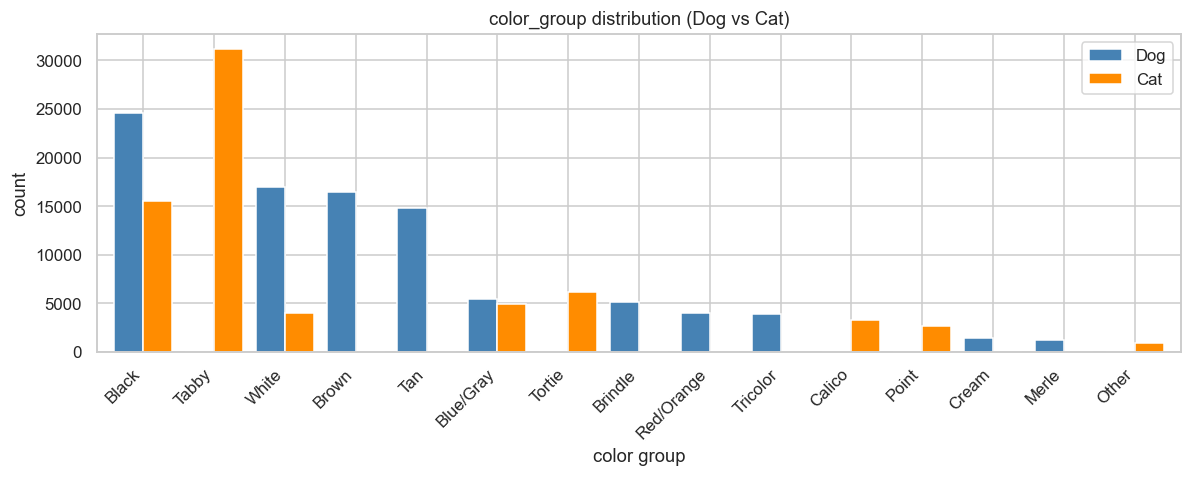

In [595]:
# bar chart of the primary color_group distribution (Dog vs Cat)
_cg = (df.groupby(['color_group', 'animal_type'], observed=True).size()
       .unstack(fill_value=0))
_cg = _cg[[c for c in ['Dog', 'Cat'] if c in _cg.columns]]
_cg = _cg.loc[_cg.sum(axis=1).sort_values(ascending=False).index]   # most common first
ax = _cg.plot(kind='bar', figsize=(11, 4.5), width=0.82,
              color={'Dog': DOG_COLOR, 'Cat': CAT_COLOR})
ax.set_xlabel('color group'); ax.set_ylabel('count')
ax.set_title('color_group distribution (Dog vs Cat)')
ax.legend(title='')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### 2.6 `outcome_subtype` distribution under each `outcome_type`
Heatmap of raw **counts** for each `outcome_subtype` × `outcome_type` pair (`(no subtype)` = subtype is NaN). A **log color scale** keeps small cells visible alongside the large ones; empty pairs are left blank. The x-axis (`outcome_type`) is placed on **top**. Both columns are **leakage** — shown only to understand how the target is built, never used as features.

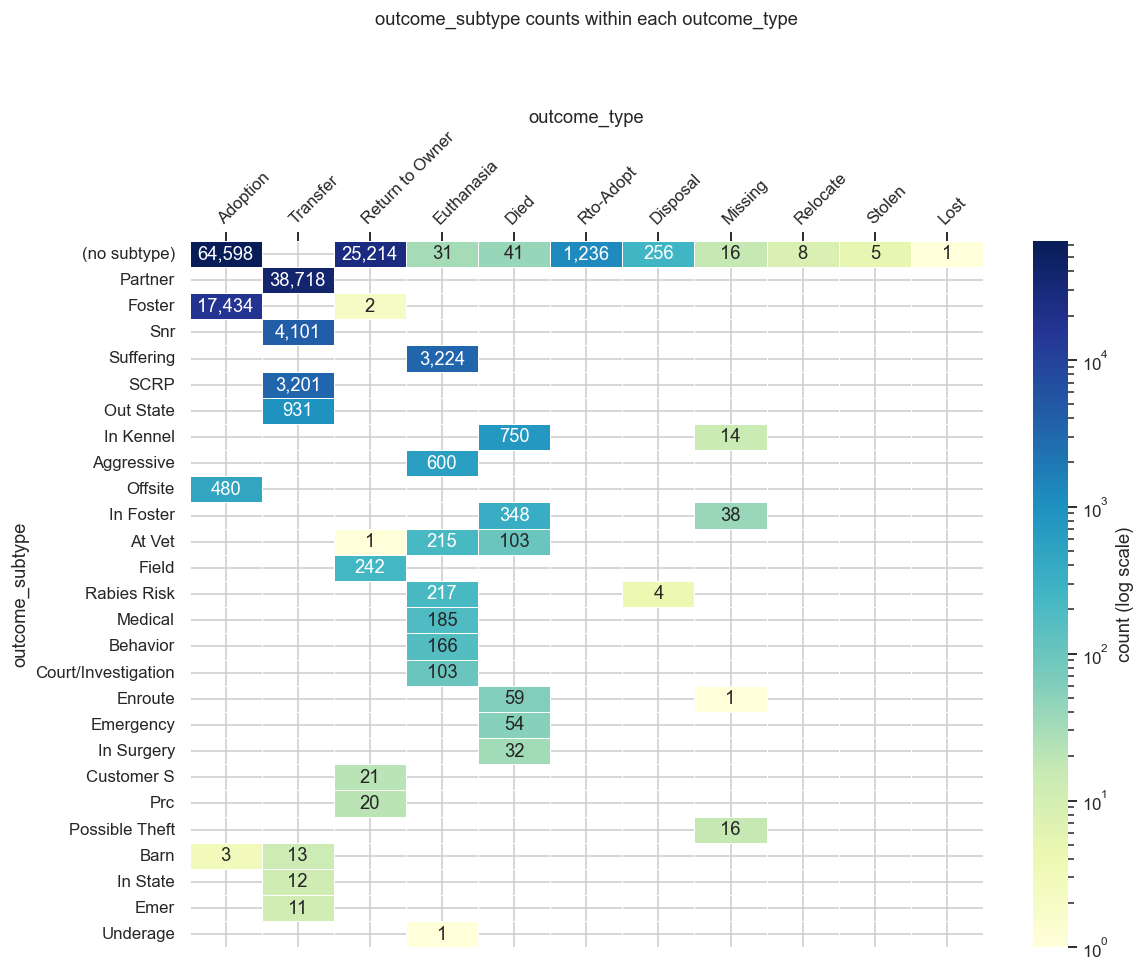

In [596]:
# outcome_subtype counts within each outcome_type (raw counts).
# Uses the full df (all dog/cat outcomes) so every outcome_type is shown.
# Both columns are LEAKAGE - displayed only to understand the target, never used as features.
from matplotlib.colors import LogNorm
ct = pd.crosstab(df['outcome_subtype'].fillna('(no subtype)'), df['outcome_type'])
ct = ct.loc[:, ct.sum(axis=0).sort_values(ascending=False).index]   # common outcome_types first
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]       # common subtypes first

annot = ct.map(lambda v: f'{v:,}' if v > 0 else '')                  # blank out empty cells
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(ct, annot=annot.values, fmt='', cmap='YlGnBu', mask=(ct == 0),
            norm=LogNorm(vmin=1, vmax=ct.values.max()),             # log scale so small cells stay visible
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'count (log scale)'}, ax=ax)
ax.set_title('outcome_subtype counts within each outcome_type', pad=55)
ax.set_xlabel('outcome_type'); ax.set_ylabel('outcome_subtype')
# put the x-axis label and ticks on the TOP of the graph
ax.xaxis.set_label_position('top')
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor')
plt.tight_layout(); plt.show()

## 3. Bivariate Analysis — features vs `is_adopted`
_Dogs and cats computed separately. Red dashed line = that species' overall adoption rate._

### 3.0 Reusable helper

In [597]:
def plot_adoption_rate_by(col, data, top_n=None, min_count=30,
                          ax=None, title=None, color='steelblue', sort='rate'):
    """Horizontal bar chart of adoption rate per category of `col` within `data`.

    - Drops categories with fewer than `min_count` rows.
    - If `top_n` is given, keeps the `top_n` most frequent categories.
    - Draws a red dashed line at this data's overall is_adopted mean.
    - Annotates each bar with its sample size (n=...).
    - sort='rate' orders bars by adoption rate; sort='index' keeps category order
      (use 'index' for ordered buckets like age_bucket).
    """
    g = data.groupby(col, observed=True)[TARGET].agg(rate='mean', n='count')
    g = g[g['n'] >= min_count]
    if top_n is not None:
        g = g.nlargest(top_n, 'n')
    g = g.sort_values('rate') if sort == 'rate' else g.sort_index()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(g))))
    labels = [str(LABEL_MAP.get(col, {}).get(i, i)) for i in g.index]
    ax.barh(labels, g['rate'].values, color=color)
    overall = data[TARGET].mean()
    ax.axvline(overall, color='red', ls='--', lw=1.5, label=f'overall {overall:.2f}')
    for y, (rate, n) in enumerate(zip(g['rate'], g['n'])):
        ax.text(min(rate + 0.01, 0.99), y, f'n={int(n)}', va='center', fontsize=8)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('adoption rate')
    ax.set_title(title or f'adoption rate by {col}')
    ax.legend(loc='lower right', fontsize=8)
    return ax

### 3.1 Adoption rate by each categorical feature (Dog | Cat)

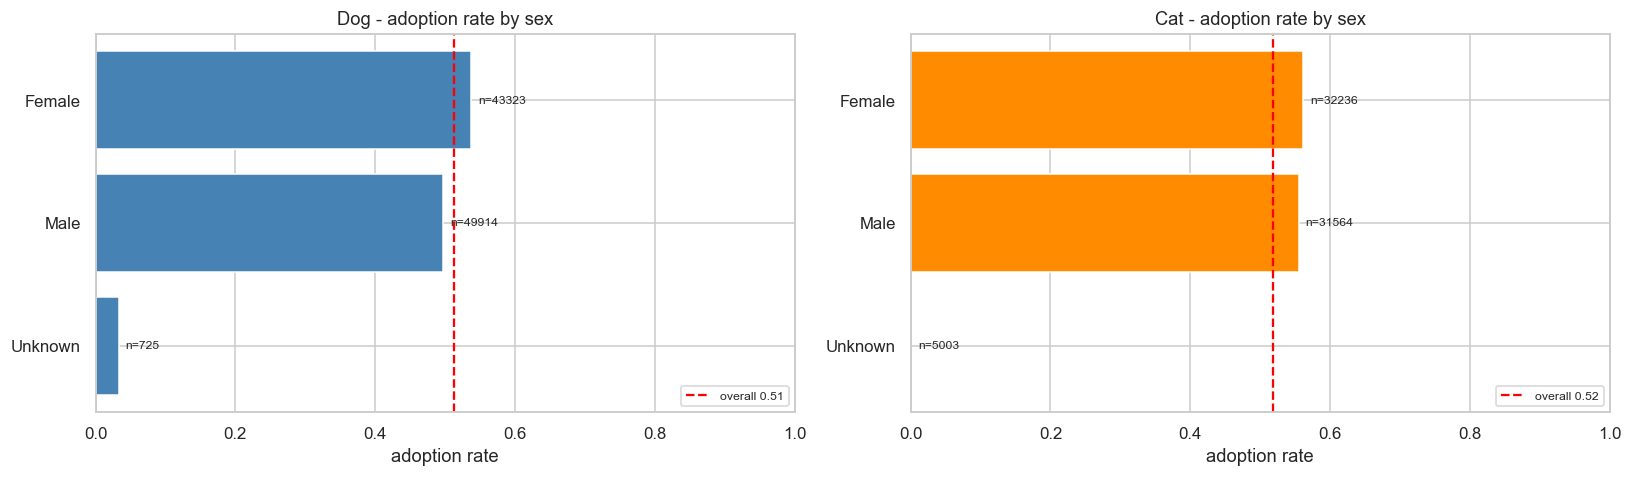

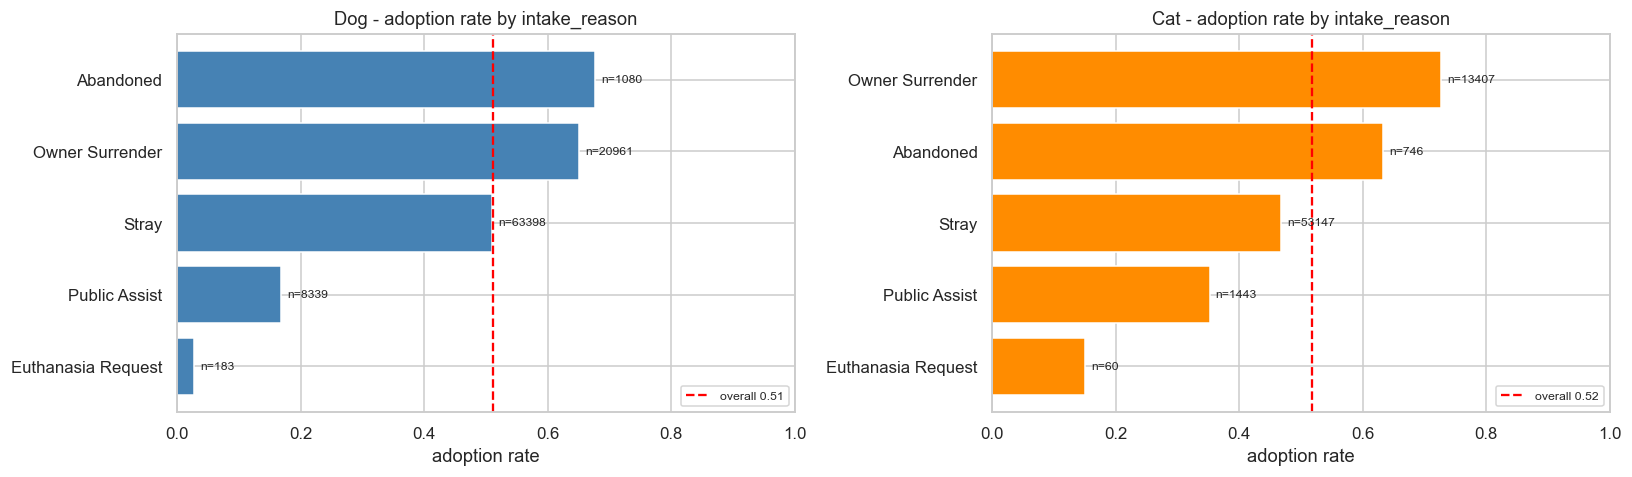

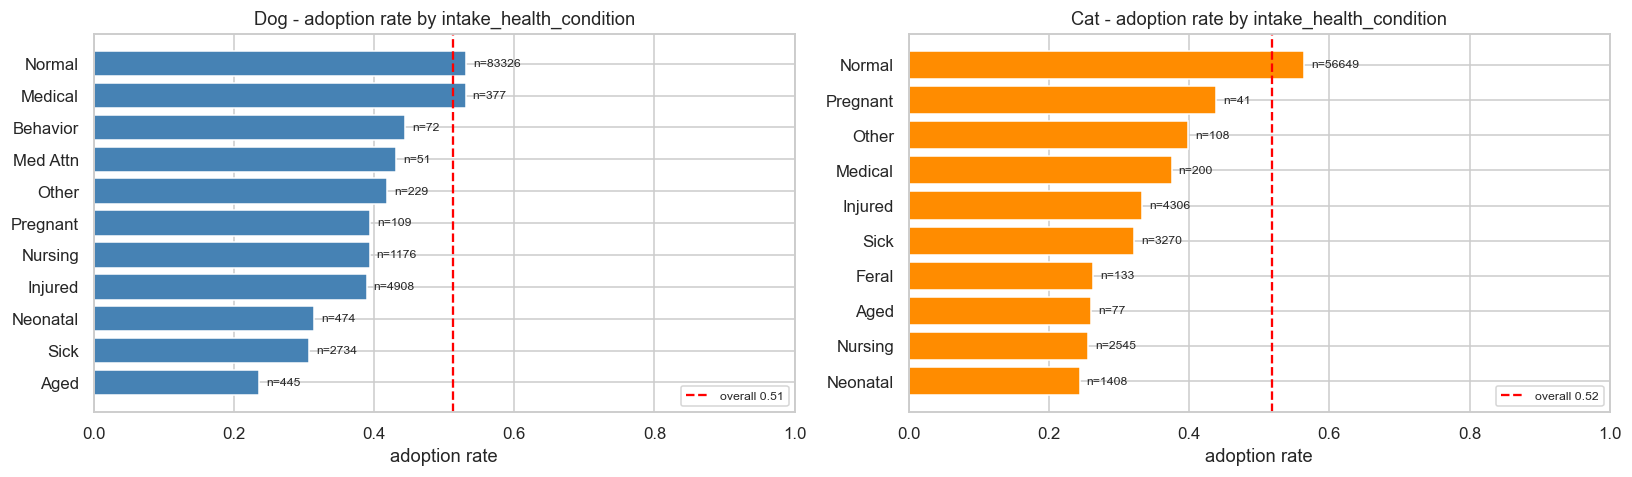

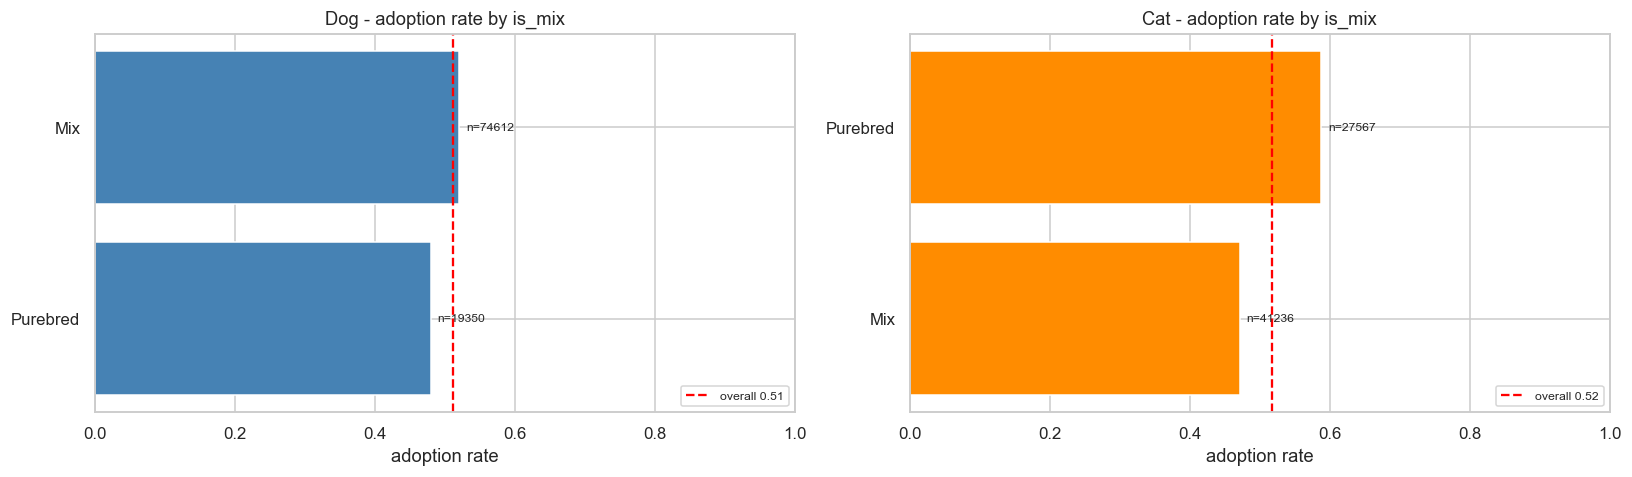

In [598]:
for col in ['sex', 'intake_reason', 'intake_health_condition', 'is_mix']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    plot_adoption_rate_by(col, dogs, ax=axes[0], min_count=30,
                          title=f'Dog - adoption rate by {col}', color=DOG_COLOR)
    plot_adoption_rate_by(col, cats, ax=axes[1], min_count=30,
                          title=f'Cat - adoption rate by {col}', color=CAT_COLOR)
    fig.tight_layout(); plt.show()

### 3.2 Adoption rate by breed (top 15 by volume, min 100 rows)

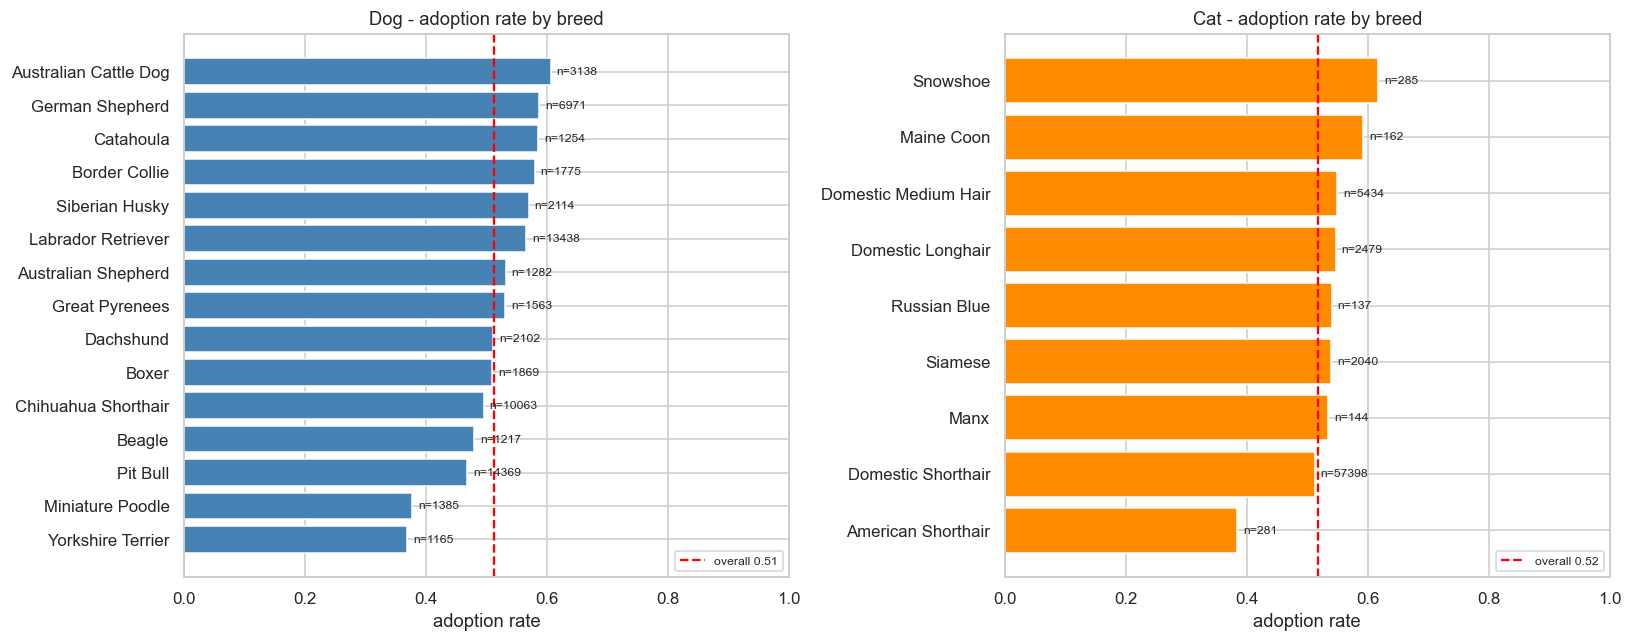

In [599]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_adoption_rate_by('primary_breed', dogs, top_n=15, min_count=100, ax=axes[0],
                      title='Dog - adoption rate by breed', color=DOG_COLOR)
plot_adoption_rate_by('primary_breed', cats, top_n=15, min_count=100, ax=axes[1],
                      title='Cat - adoption rate by breed', color=CAT_COLOR)
fig.tight_layout(); plt.show()

### 3.3 Adoption rate by age bucket (Dog | Cat)

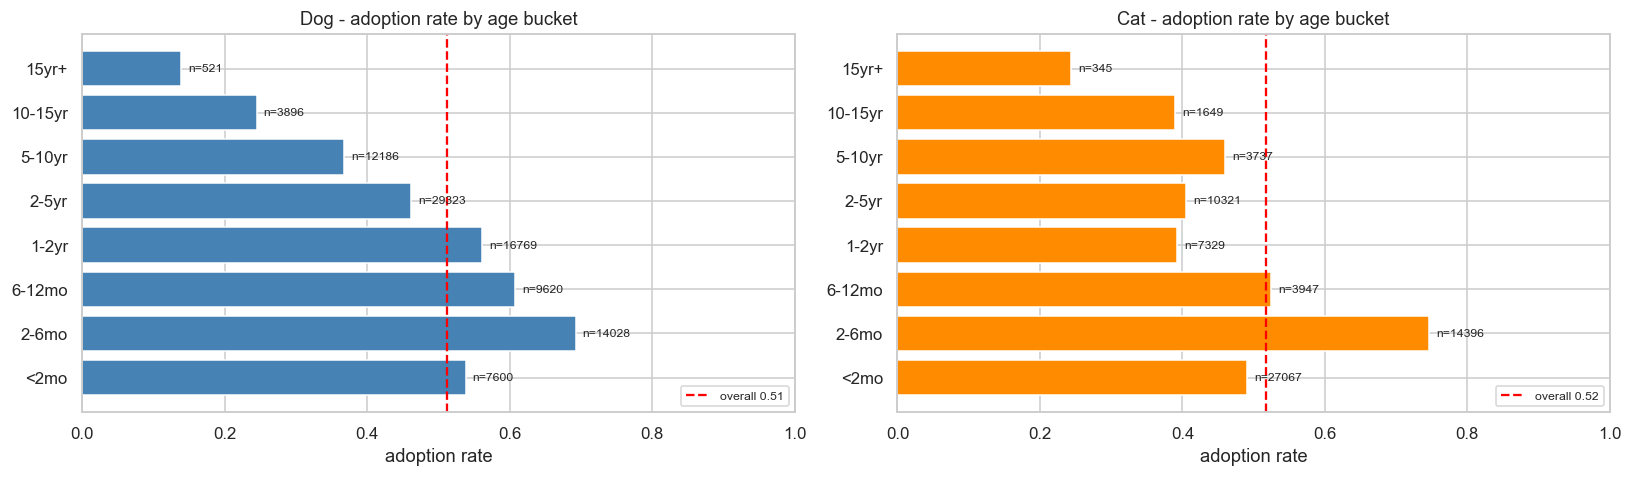

In [600]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_adoption_rate_by('age_bucket', dogs, ax=axes[0], min_count=30, sort='index',
                      title='Dog - adoption rate by age bucket', color=DOG_COLOR)
plot_adoption_rate_by('age_bucket', cats, ax=axes[1], min_count=30, sort='index',
                      title='Cat - adoption rate by age bucket', color=CAT_COLOR)
fig.tight_layout(); plt.show()

### 3.4 Adoption rate by grouped color (Dog | Cat)
The grouped view is far more readable than the 50+ raw colors above. Shown for both `color_group` (primary) and `secondary_color_group` — for the latter, `single color` means the animal has no secondary color.

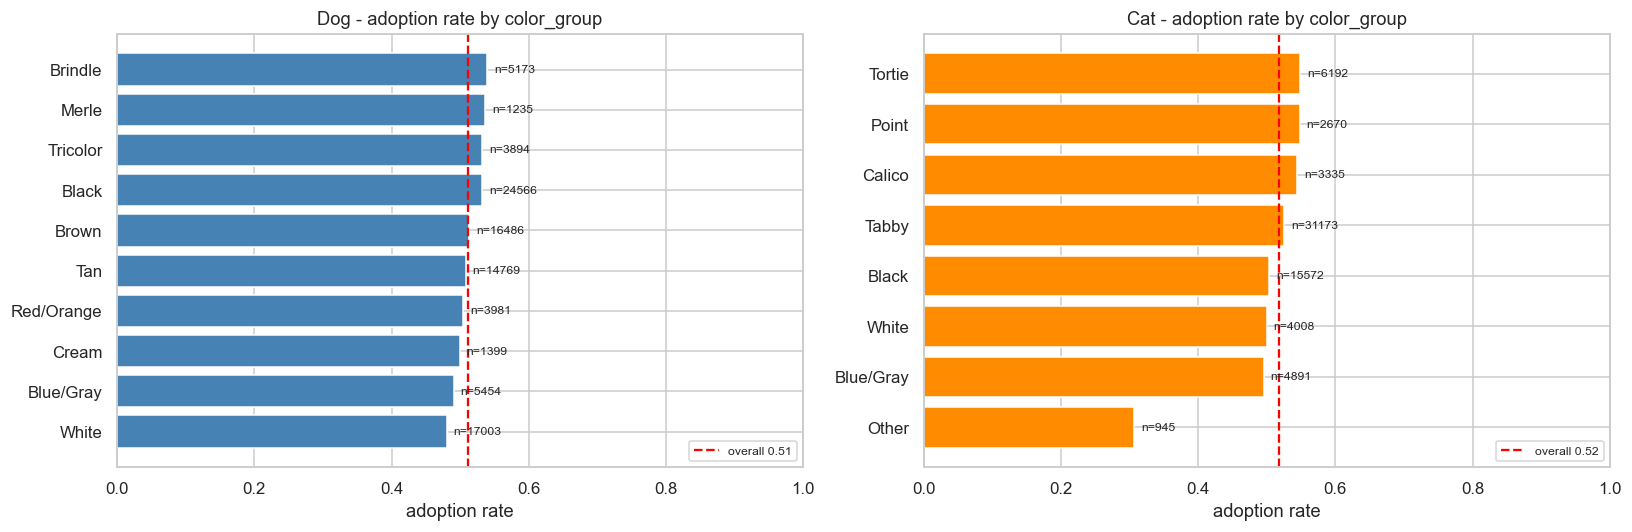

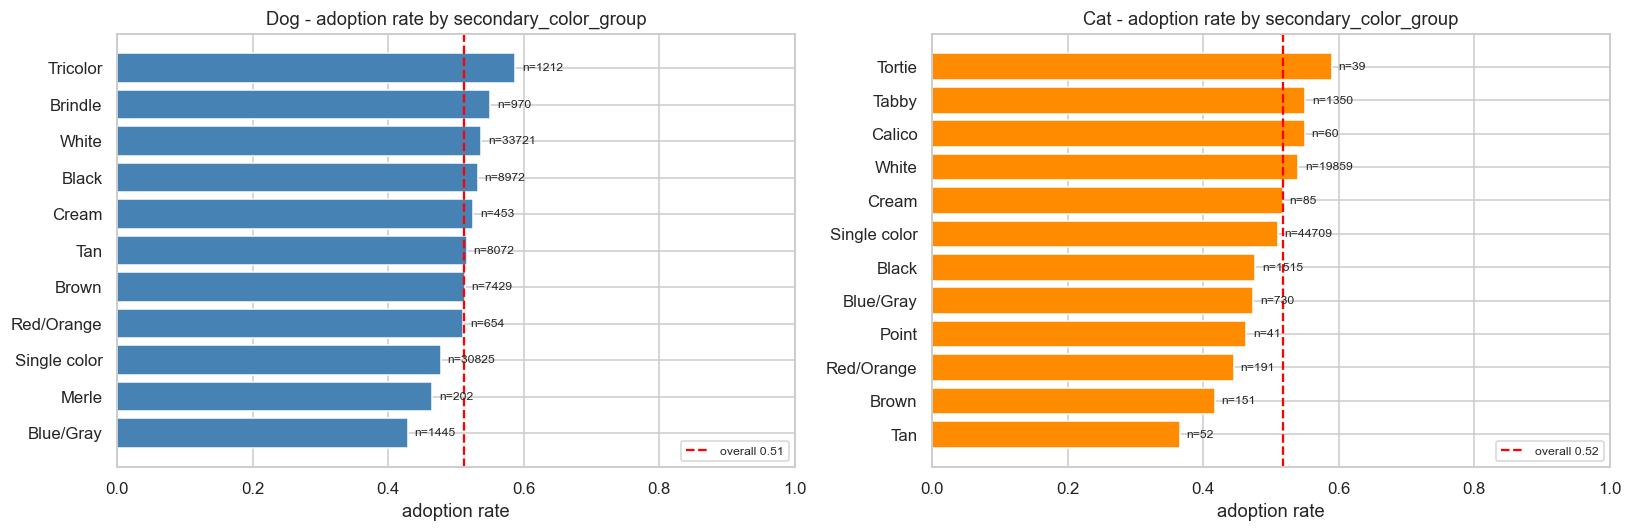

In [601]:
for col in ['color_group', 'secondary_color_group']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plot_adoption_rate_by(col, dogs, ax=axes[0], min_count=30,
                          title=f'Dog - adoption rate by {col}', color=DOG_COLOR)
    plot_adoption_rate_by(col, cats, ax=axes[1], min_count=30,
                          title=f'Cat - adoption rate by {col}', color=CAT_COLOR)
    fig.tight_layout(); plt.show()

## 4. Multivariate

### 4.1 Headline: dog vs cat adoption rate by age bucket (one chart)
This is the key reason the two species must not be pooled.

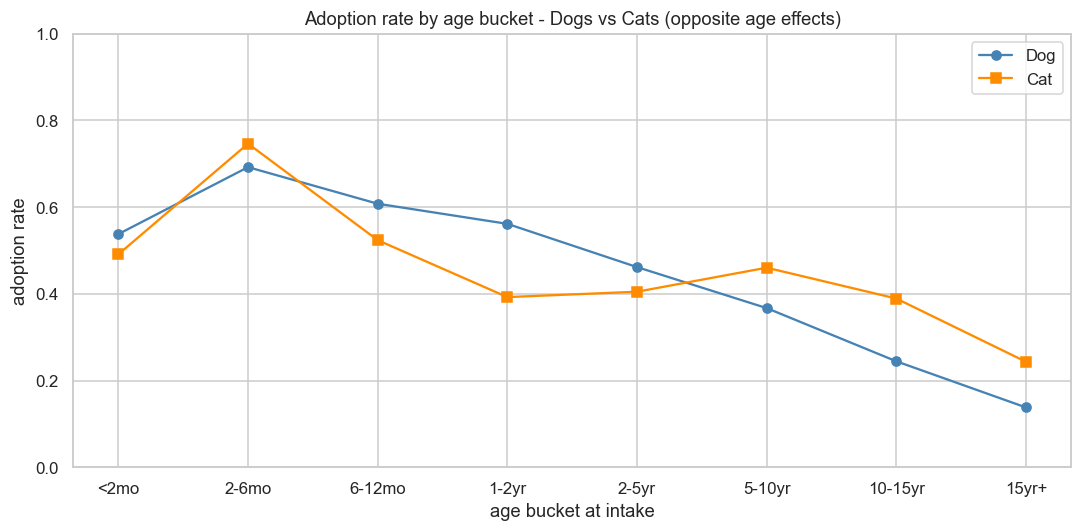

              Dog    Cat
age_bucket              
<2mo        0.538  0.491
2-6mo       0.692  0.747
6-12mo      0.608  0.524
1-2yr       0.562  0.393
2-5yr       0.462  0.405
5-10yr      0.367  0.461
10-15yr     0.245  0.389
15yr+       0.138  0.243


In [602]:
dog_rate = dogs.groupby('age_bucket', observed=True)[TARGET].mean().reindex(AGE_LABELS)
cat_rate = cats.groupby('age_bucket', observed=True)[TARGET].mean().reindex(AGE_LABELS)

plt.figure(figsize=(10, 5))
plt.plot(AGE_LABELS, dog_rate.values, marker='o', color=DOG_COLOR, label='Dog')
plt.plot(AGE_LABELS, cat_rate.values, marker='s', color=CAT_COLOR, label='Cat')
plt.ylabel('adoption rate'); plt.xlabel('age bucket at intake')
plt.title('Adoption rate by age bucket - Dogs vs Cats (opposite age effects)')
plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

print(pd.DataFrame({'Dog': dog_rate, 'Cat': cat_rate}).round(3))

### 4.2 Correlation heatmaps — computed separately per species
Encoded numeric view: `is_mix`, `is_sn` (previously spayed/neutered), `health_normal` (intake condition == Normal), `age_days`, and the target.

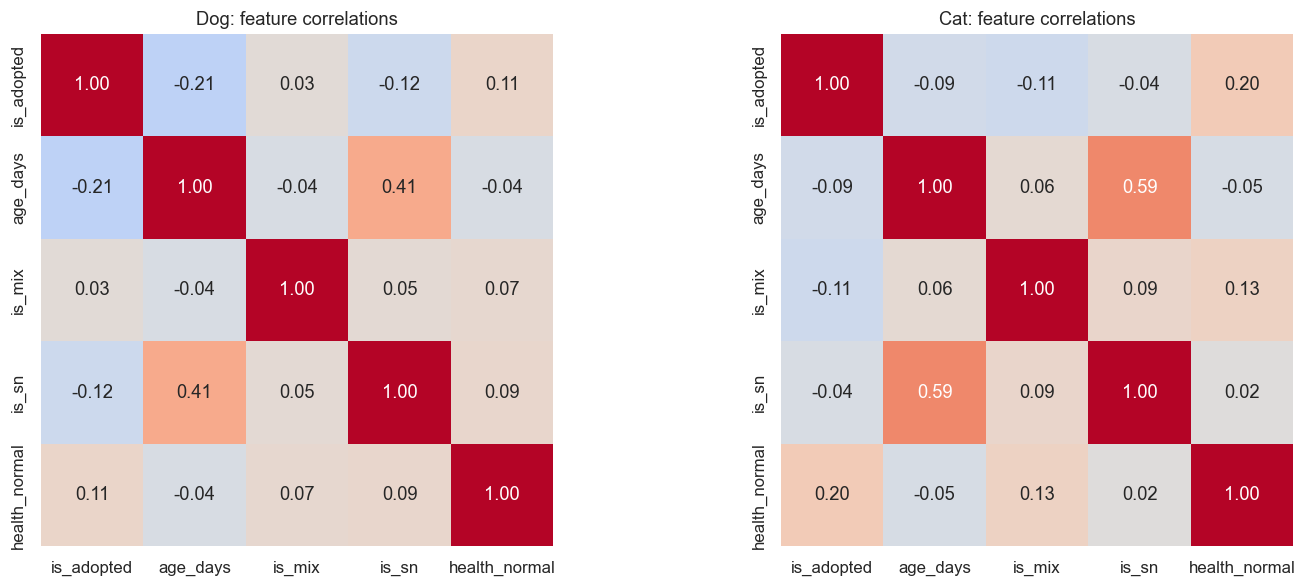

In [603]:
def encode_for_corr(frame):
    return pd.DataFrame({
        'is_adopted':    frame[TARGET],
        'age_days':      frame['age_at_intake_days'],
        'is_mix':        frame['is_mix'],
        'is_sn':      frame['is_previously_spayed_neutered'],
        'health_normal': (frame['intake_health_condition'] == 'Normal').astype(int),
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (sp, frame) in zip(axes, [('Dog', dogs), ('Cat', cats)]):
    corr = encode_for_corr(frame).corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f'{sp}: feature correlations')
fig.tight_layout(); plt.show()

### 4.3 Color × sex association (Dog | Cat)
Both are categorical, so the "correlation matrix" is built by one-hot encoding `color_group` (grouped `primary_color`) and `sex`, then correlating each color group against each sex (point-biserial on 0/1 dummies). Watch the cats: tortie & calico coats are almost always **female** (the coat-color gene is X-linked).

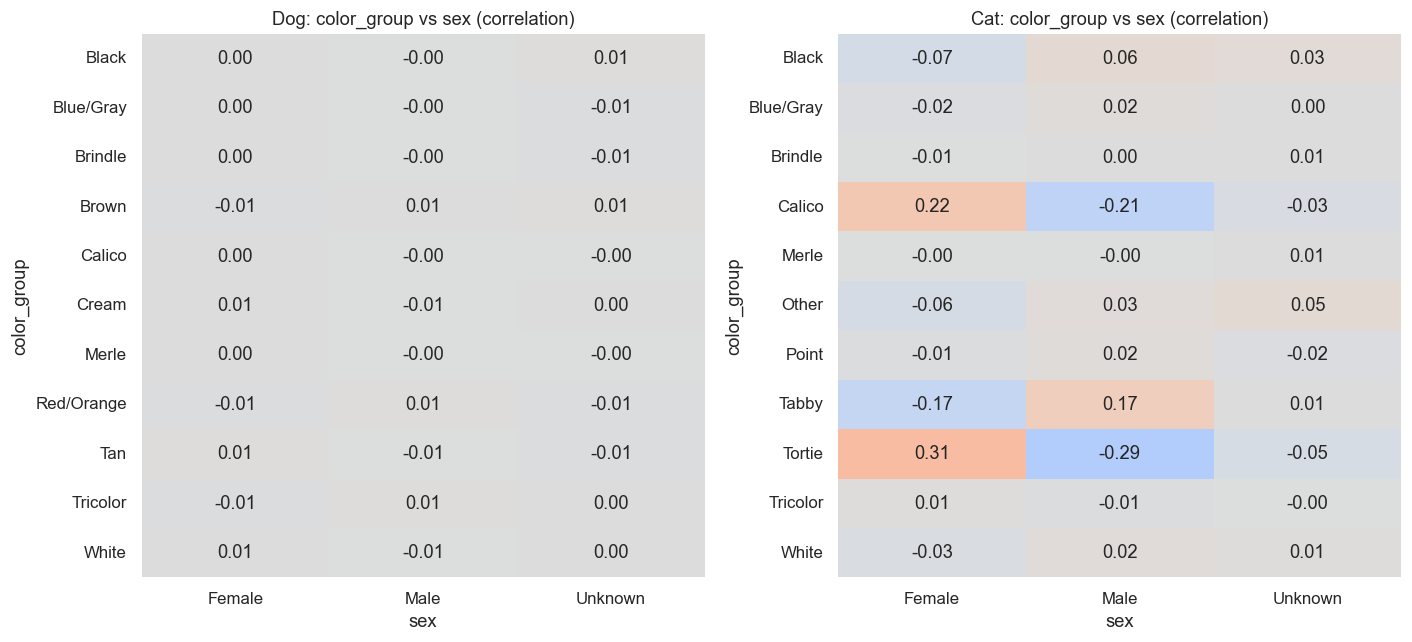

In [604]:
def color_sex_corr(frame, color_col='color_group'):
    """Correlation of each color-group indicator (rows) with each sex indicator (cols)."""
    cd = pd.get_dummies(frame[color_col]).astype(int)
    sd = pd.get_dummies(frame['sex']).astype(int)
    return pd.DataFrame(
        {s: cd.apply(lambda col: np.corrcoef(col, sd[s])[0, 1]) for s in sd.columns}
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (sp, frame) in zip(axes, [('Dog', dogs), ('Cat', cats)]):
    M = color_sex_corr(frame)
    sns.heatmap(M, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, cbar=False, ax=ax)
    ax.set_title(f'{sp}: color_group vs sex (correlation)')
    ax.set_xlabel('sex'); ax.set_ylabel('color_group')
fig.tight_layout(); plt.show()

## 5. Temporal Analysis
_Uses the full `df` (all outcomes) for intake volume;

**2013 and 2025 are partial years** - exclude them when reading year-over-year trends.

### 5.1 Intake volume per year

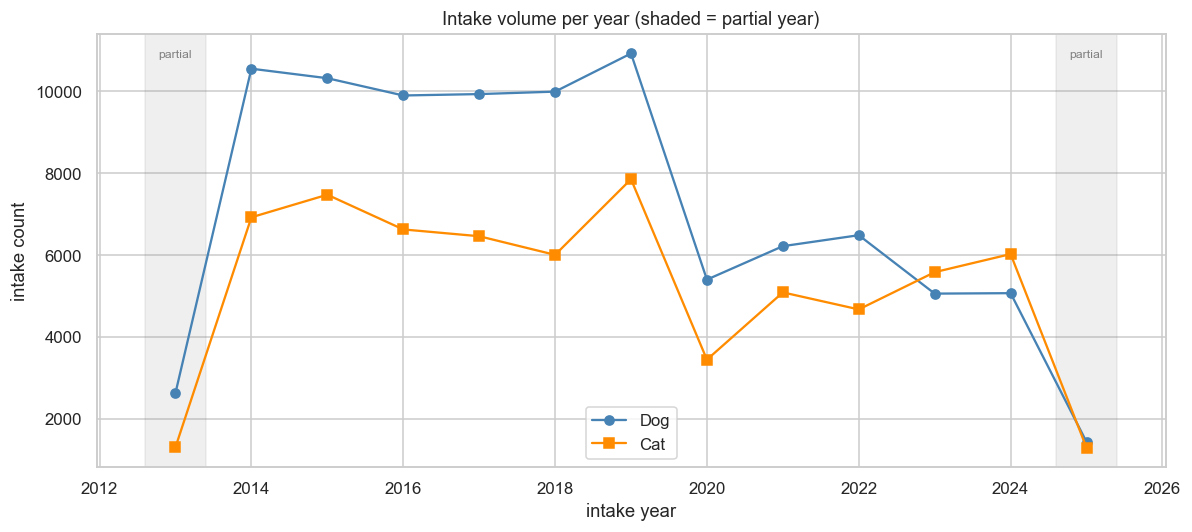

In [605]:
yearly = df.groupby(['intake_year', 'animal_type']).size().unstack()
plt.figure(figsize=(11, 5))
plt.plot(yearly.index, yearly['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(yearly.index, yearly['Cat'], marker='s', color=CAT_COLOR, label='Cat')
for yr in (2013, 2025):
    plt.axvspan(yr - 0.4, yr + 0.4, color='grey', alpha=0.12)
plt.text(2013, plt.ylim()[1]*0.95, 'partial', ha='center', fontsize=8, color='grey')
plt.text(2025, plt.ylim()[1]*0.95, 'partial', ha='center', fontsize=8, color='grey')
plt.ylabel('intake count'); plt.xlabel('intake year')
plt.title('Intake volume per year (shaded = partial year)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Seasonality: intake volume per month (kitten-season check)
Expect **cats to spike May-Sep**.

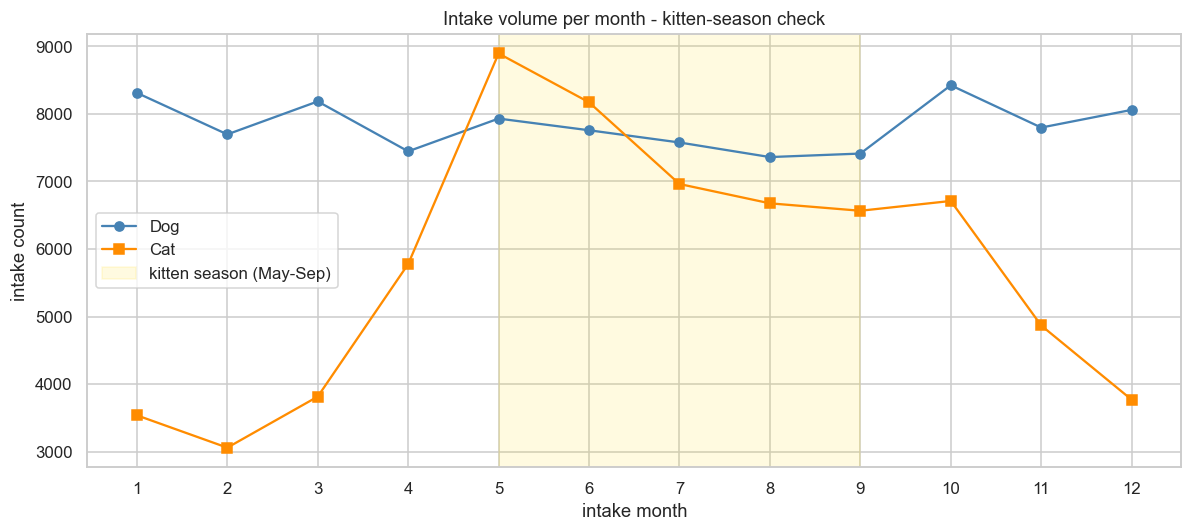

In [606]:
monthly = df.groupby(['intake_month', 'animal_type']).size().unstack()
plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(monthly.index, monthly['Cat'], marker='s', color=CAT_COLOR, label='Cat')
plt.axvspan(5, 9, color='gold', alpha=0.12, label='kitten season (May-Sep)')
plt.xticks(range(1, 13))
plt.ylabel('intake count'); plt.xlabel('intake month')
plt.title('Intake volume per month - kitten-season check')
plt.legend(); plt.tight_layout(); plt.show()

### 5.3 Adoption rate per year (data-drift check)
Overall adoption rate has risen over time (~42% in 2013 to ~66% in 2024).

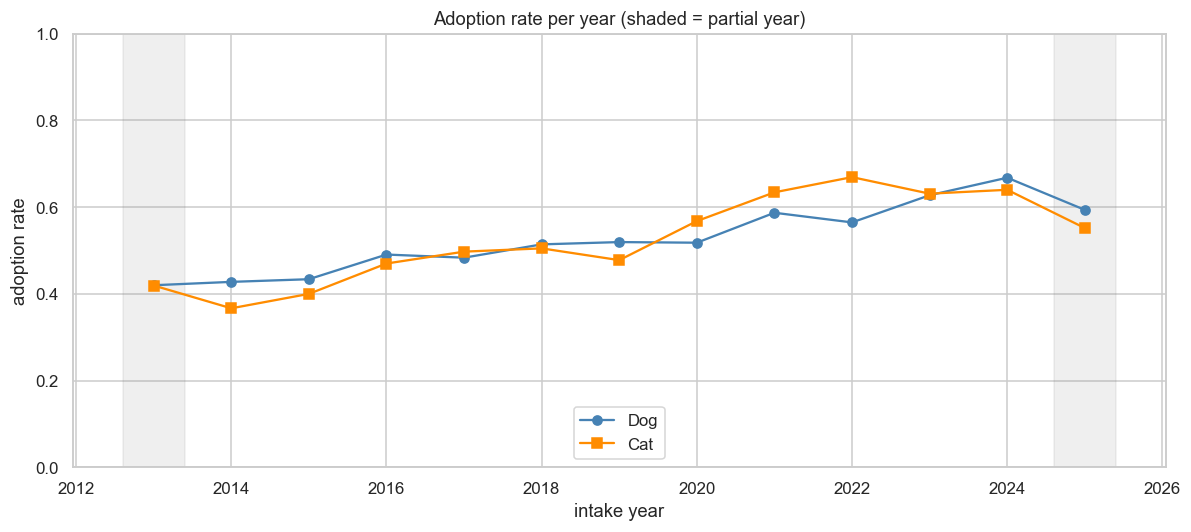

animal_type    Cat    Dog
intake_year              
2013         0.419  0.420
2014         0.367  0.428
2015         0.400  0.434
2016         0.470  0.491
2017         0.498  0.484
2018         0.505  0.514
2019         0.478  0.520
2020         0.568  0.518
2021         0.634  0.587
2022         0.669  0.565
2023         0.631  0.628
2024         0.640  0.668
2025         0.552  0.594


In [607]:
yr_rate = df.groupby(['intake_year', 'animal_type'])[TARGET].mean().unstack()
plt.figure(figsize=(11, 5))
plt.plot(yr_rate.index, yr_rate['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(yr_rate.index, yr_rate['Cat'], marker='s', color=CAT_COLOR, label='Cat')
for yr in (2013, 2025):
    plt.axvspan(yr - 0.4, yr + 0.4, color='grey', alpha=0.12)
plt.ylabel('adoption rate'); plt.xlabel('intake year'); plt.ylim(0, 1)
plt.title('Adoption rate per year (shaded = partial year)')
plt.legend(); plt.tight_layout(); plt.show()

print(yr_rate.round(3))